# SHAP Analysis

In [1]:
# Import libraries
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import random

import pyarrow as pa
import pyarrow.parquet as pq
import sklearn
import shap
import matplotlib.pyplot as plt

In [46]:
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'
model_dir = future_dir + "Models"
shap_dir = future_dir + "SHAP"

# Load Data

dataset1 = 'Dataset_RF_Model_SW_COMIDS.csv'
#dataset1 = 'Dataset_RF_Model_GW_COMIDS.csv'

modelpath = "/torch_models_kfold_future_NO3_sw.pth"
#modelpath = "/torch_models_kfold_future_NO3_gw.pth"

testnames = "/test_datasets_sw.pkl"
#testnames = "/test_datasets_gw.pkl"

trainnames = "/train_datasets_sw.pkl"
#trainnames = "/train_datasets_gw.pkl"


In [3]:
# Load Observation Dataset


input_data_ = pd.read_csv(future_dir+dataset1)
input_data = input_data_.drop(columns=['COMID','viol_freq']) 
#y = input_data['Viol_Class'].values
#ncols = input_data.shape[1]
#ncols

In [64]:
input_data.shape, input_data_.shape

((14934, 14), (14934, 16))

In [4]:
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler

X_input_data = input_data.drop(columns=['Viol_Class']).values
X_input_data.shape

#  Convert to tensor data
X_input_data = torch.from_numpy(X_input_data).type(torch.float)
X_input_data.shape,X_input_data.dtype

# Find the size of the smallest class
min_size = input_data['Viol_Class'].value_counts().min()

min_size  = min_size * 10

# Sample exactly 'min_size' elements from each binary group
#balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42).reset_index(drop=True)

# If increasing the min_size, you can use the 'replace=True' argument to allow for sampling with replacement
balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42, replace=True).reset_index(drop=True)


# Convert to tensors and split into train and test sets
from sklearn.model_selection import train_test_split
#X = input_data.drop(columns=['Viol_Class']).values # when use this the model just predicts the majority class
#y = input_data['Viol_Class'].values
X = balanced_df.drop(columns=['Viol_Class']).values
y = balanced_df['Viol_Class'].values

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Make a copy to use later
X_full = X.clone()
y_full = y.clone()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=2
)

nrows = X_train.size()[0]
ncols = X_train.size()[1]
X_tensor = X.clone().detach()
y_tensor = y.clone().detach().unsqueeze(1) # Shape: [1000, 1] for BCELoss
dataset = TensorDataset(X_tensor, y_tensor)
len(dataset)

C:\Users\MPennino\AppData\Local\Temp\ipykernel_43756\1694839807.py:31: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at D:\bld\libtorch_1784990676194\work\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


820

In [5]:
batchsize = int(len(dataset) * 0.2)
batchsize

164

In [22]:
# Load Train Datasets
import pickle
from torch.utils.data import DataLoader

with open(model_dir + trainnames, "rb") as f:
    Test_datasets = pickle.load(f)

# Recreate your list of DataLoaders
train_loaders = [DataLoader(ds, batch_size=batchsize, shuffle=True) for ds in Test_datasets]

In [6]:
import torch
import torch.nn as nn

class ImprovedBinaryClassifier(nn.Module):
    def __init__(self, input_dim=ncols, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),             # Prevents dead neurons
            nn.BatchNorm1d(hidden_dim),     # Stabilizes training
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),                # Prevents overfitting
            
            nn.Linear(hidden_dim, 1)        # Outputs raw logits (No Sigmoid here!)
        )
        
    def forward(self, x):
        return self.network(x)

In [7]:
# Model for kfold models
checkpoint = torch.load(model_dir + modelpath, weights_only=False)
len(checkpoint)

loaded_models = [ImprovedBinaryClassifier() for _ in range(len(checkpoint))]  # List comprehension for brevity

models = []
# 3. Restore the weights for each individual model
for i, model in enumerate(loaded_models):
    model.load_state_dict(checkpoint[f"model_{i}"])

    models.append(model)

    # 4. ALWAYS switch to evaluation mode if you are ready to test/predict!
    #model.eval()
    #print(i)
len(models), type(models[0])

(10, __main__.ImprovedBinaryClassifier)

In [9]:
#pred_data.head(3)
X_full.shape, X_input_data.shape, X_full.dtype, X_input_data.dtype, len(X_input_data)

(torch.Size([820, 13]),
 torch.Size([14934, 13]),
 torch.float32,
 torch.float32,
 14934)

In [17]:
len(models), len(train_loaders)

(10, 10)

In [23]:
for i in range(len(models)):        
    val_loader = train_loaders[i]
    
    # Convert the dataloader into a Python iterator
    data_iterator = iter(val_loader)

    # Grab the first mini-batch
    train_inputs, train_targets = next(data_iterator)
len(train_inputs), type(train_inputs)

(164, torch.Tensor)

# Calculate Average SHAP across all k-folds

In [40]:
X_input_data.shape

torch.Size([14934, 13])

In [ ]:
# SW: 71 minutes for all 10 models
import numpy as np
import shap

# List to store SHAP values from each model
all_shap_values = []

# Loop through your list of loaded models
for model, train_it in zip(models,train_loaders):
        
    # Convert the dataloader into a Python iterator
    data_iterator = iter(train_it)

    # Grab the first mini-batch
    train_inputs, train_targets = next(data_iterator)

    # 1. Create a distinct explainer for each model
    explainer = shap.GradientExplainer(model, train_inputs)
    
    # 2. Calculate SHAP values for the input data
    shap_values = explainer(X_input_data) # using same full input dataset, but different explainer based on each k-fold model
    
    # 3. Extract the raw values (.values attribute)
    all_shap_values.append(shap_values.values)

In [27]:
# Average the SHAP values across the model axis (axis 0)
mean_shap_values = np.mean(all_shap_values, axis=0)

# Put the averaged values back into an Explanation object for plotting
averaged_explanation = shap.Explanation(
    values=mean_shap_values,
    base_values=shap_values.base_values, # Note: You may want to average base_values too if they differ
    data=X_input_data,
    feature_names=X_input_data.columns if hasattr(X_input_data, 'columns') else None
)

In [54]:
# Add in feature names to shap_values object
names = input_data.columns.tolist()
names = names[:-1] 
averaged_explanation.feature_names = names

In [35]:
type(averaged_explanation)

shap._explanation.Explanation

C:\Users\MPennino\AppData\Local\Temp\ipykernel_43756\2531358622.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(averaged_explanation[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


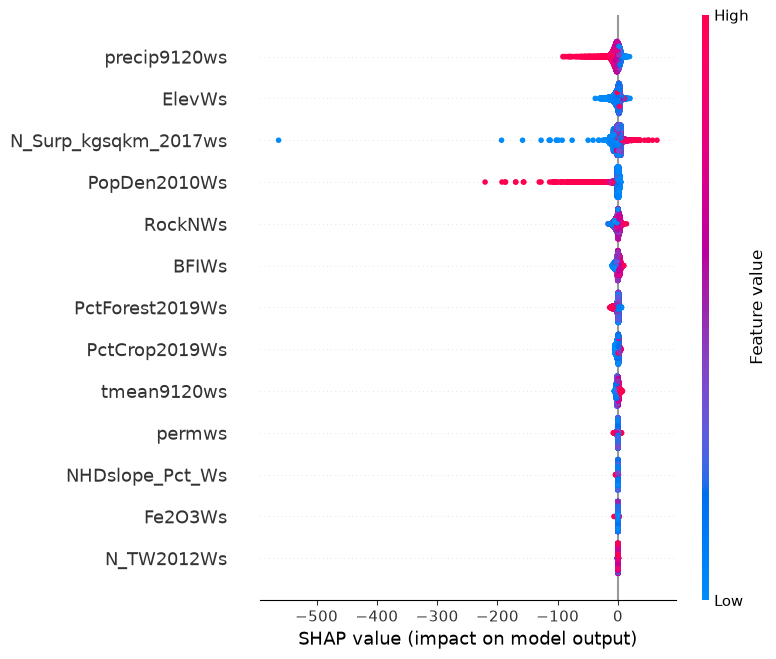

In [55]:
#shap.summary_plot(averaged_explanation, X_input_data.numpy(),feature_names=names) 
shap.summary_plot(averaged_explanation[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


# Save SHAP results

In [60]:
# Creates a DataFrame of SHAP values
import pandas as pd

df_shap = pd.DataFrame(
    data=averaged_explanation[:,:, 0].values, 
    columns=averaged_explanation[:, :, 0].feature_names
)
#df_shap.head(5)
df_shap.shape, type(df_shap)#, df_shap.head()

((14934, 13), pandas.DataFrame)

In [68]:
# Add back on COMIDs with "cbind"
#input_data_.shape, df_shap.shape
df_shap2 = pd.concat([input_data_['COMID'], df_shap], axis=1)
df_shap2.shape, df_shap.shape#, df_shap2.head()


((14934, 14), (14934, 13))

In [70]:
shap_dir

'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/SHAP'

In [71]:
# Save SHAP Results DataFrame

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
filename1 = '/torch_SHAP_Values_kfold_DF_COMID_All_Observed_sw.parquet'
table1 = pa.Table.from_pandas(df_shap2)

pq.write_table(table1, shap_dir + filename1)


In [59]:
# Save SHAP Results as shap._explanation.Explanation file
import pickle

filename2 = '/torch_SHAP_Values_kfold_COMID_All_Observed_sw.pkl'

with open(shap_dir + filename2, "wb") as f:
    pickle.dump(averaged_explanation, f)

# Scatter Plots

Text(0, 0.5, 'SHAP Value')

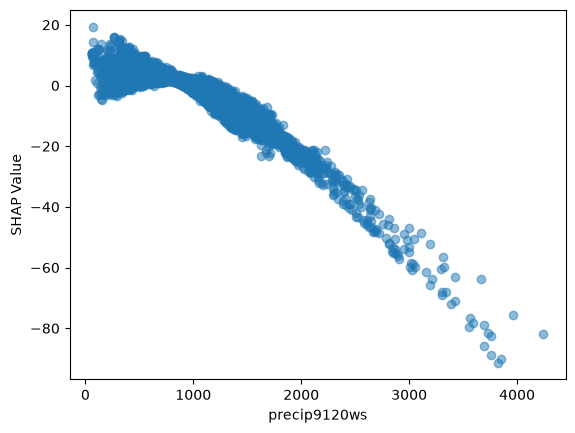

In [41]:
# Test out plotting SHAP values against input data by changing the index of the input data and shap values
indexN = 3
plt.scatter(X_input_data[:, indexN], averaged_explanation[:,:, 0][:, indexN].values, alpha=0.5)
plt.xlabel(names[indexN])
plt.ylabel('SHAP Value')

In [43]:
## Function to plot shap vs. input values (for multiple plots)
def plot_shap_vs_input(shap_values, input_values, feature_names):

    fig, axes = plt.subplots(3, 4,figsize=(12, 8))

    # Flattening the axes array makes it easier to loop through
    for i, ax in enumerate(axes.flat, start=1):
        ax.scatter(input_values[:, i-1], shap_values[:, i-1])
        
        # Use set_xlabel and set_ylabel for individual subplot axes
        ax.set_xlabel(f"{feature_names[i-1]}")
        ax.set_ylabel("SHAP Value")

    plt.tight_layout()
    plt.show()

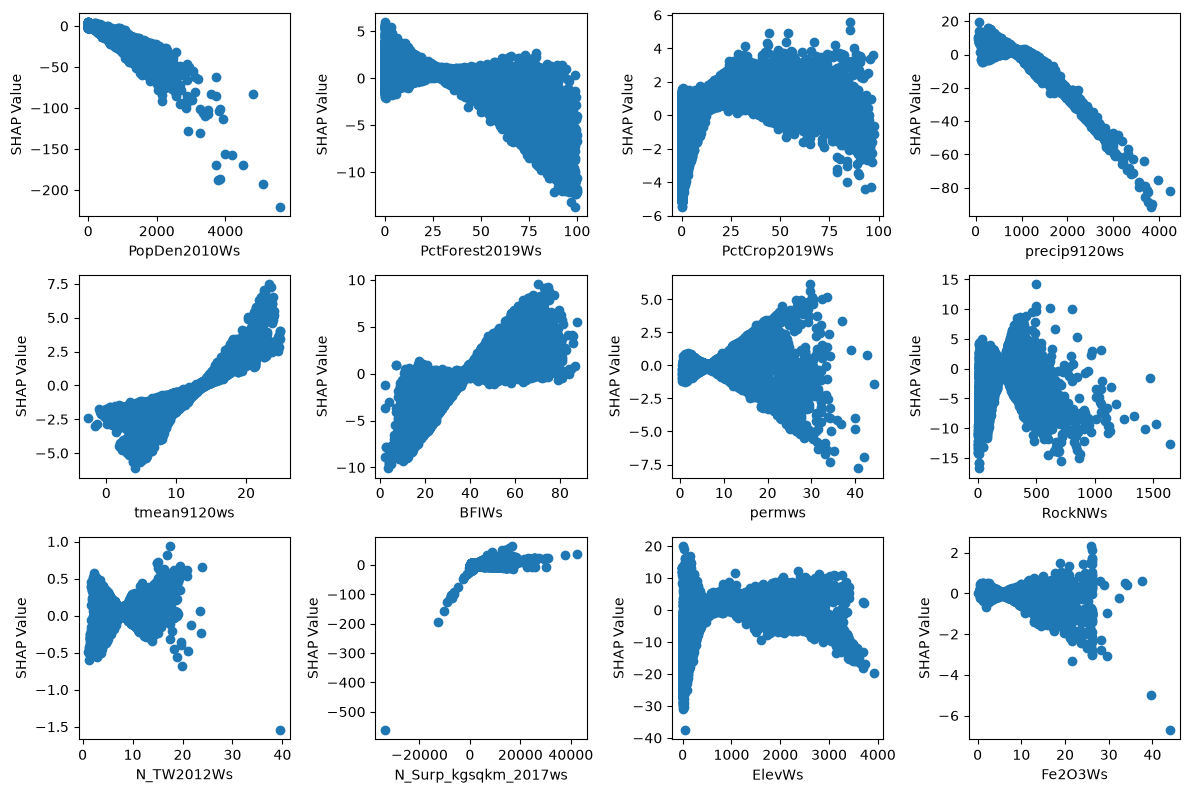

In [44]:
plot_shap_vs_input(averaged_explanation[:,:, 0].values, X_input_data.numpy(), names)

# Original Method:

In [32]:
# Need to pull out one of the models for the SHAP analysis - later could run SHAP for each 
loaded_model = models[0]
loaded_model.eval()

ImprovedBinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [33]:
# Create Explainer object that can calculate shap values
explainer0 = shap.GradientExplainer(loaded_model,X_train)

In [ ]:
# Calculate Shap values
shap_values0 = explainer0(X_input_data) # 7 min for 15,000 rows for SW,62 min 4.3 sec (115842 rows GW),


In [36]:
# Add in feature names to shap_values object
names = input_data.columns.tolist()
names = names[:-1] 
shap_values1 = shap_values0
shap_values1.feature_names = names

In [37]:
# Creates a DataFrame of SHAP values
df_shap = pd.DataFrame(
    data=shap_values1[:,:, 0].values, 
    columns=shap_values1[:, :, 0].feature_names
)
#df_shap.head(5)
df_shap.shape, type(shap_values)

((14934, 13), shap._explanation.Explanation)

C:\Users\MPennino\AppData\Local\Temp\ipykernel_43756\784512701.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


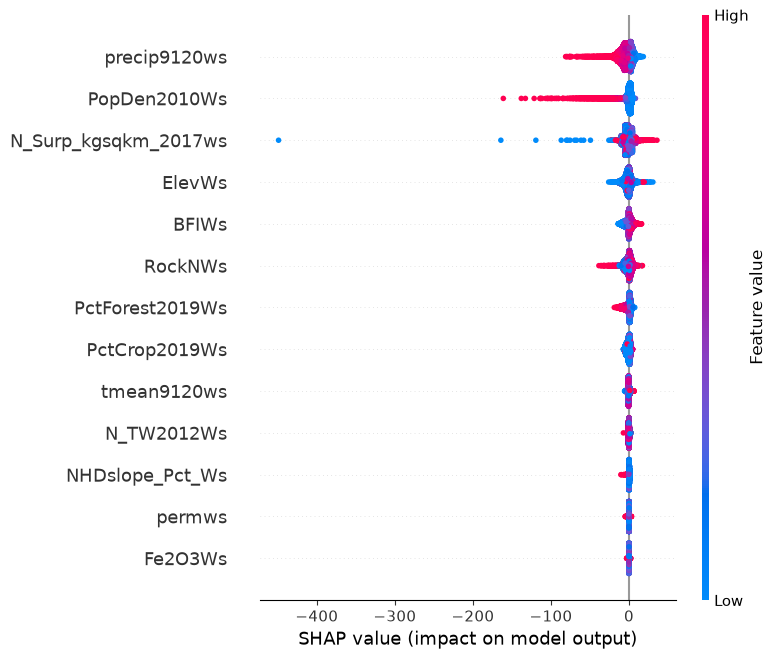

In [38]:
# Visualize
#shap.summary_plot(shap_values[0], X_test.numpy())
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy()) # works but no feature names
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy(),feature_names=names) # works if generate shape values based on test dataset
#shap.summary_plot(shap_values1[:,:, 0].values, X_full.numpy(),feature_names=names) # works if generate shape values based on test dataset

# This one use to work
shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset

#shap.summary_plot(shap_values1[:,:, 0].values, input_data[0:393:].drop(columns=['Viol_Class'])) 

# SHAP Scatter Plots

Text(0, 0.5, 'SHAP Value')

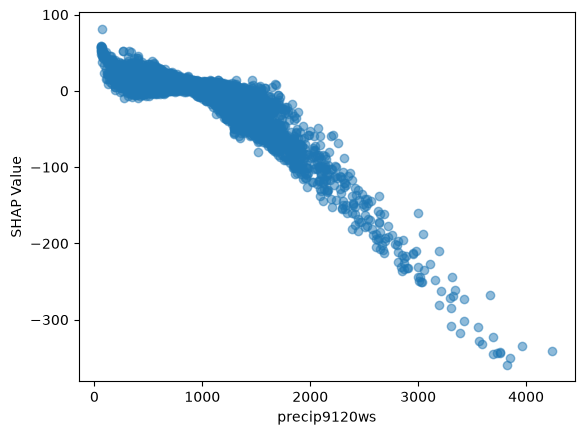

In [ ]:
# Test out plotting SHAP values against input data by changing the index of the input data and shap values
indexN = 3
plt.scatter(X_input_data[:, indexN], shap_values1[:,:, 0][:, indexN].values, alpha=0.5)
plt.xlabel(names[indexN])
plt.ylabel('SHAP Value')

In [ ]:
## Function to plot shap vs. input values
# This plots all figures separately.
# def plot_shap_vs_input(shap_values, input_values, feature_names):
#     for i, feature in enumerate(feature_names):
#         plt.scatter(input_values[:, i], shap_values[:, i], alpha=0.5)
#         plt.xlabel(feature)
#         plt.ylabel('SHAP Value')
#         plt.title(f'SHAP Values for {feature}')
#         plt.show()

In [49]:
def plot_shap_vs_input2(shap_values, input_values, feature_names):

    fig, axes = plt.subplots(3, 4,figsize=(12, 8))

    # Flattening the axes array makes it easier to loop through
    for i, ax in enumerate(axes.flat, start=1):
        ax.scatter(input_values[:, i-1], shap_values[:, i-1])
        
        # Use set_xlabel and set_ylabel for individual subplot axes
        ax.set_xlabel(f"{feature_names[i-1]}")
        ax.set_ylabel("SHAP Value")

    plt.tight_layout()
    plt.show()

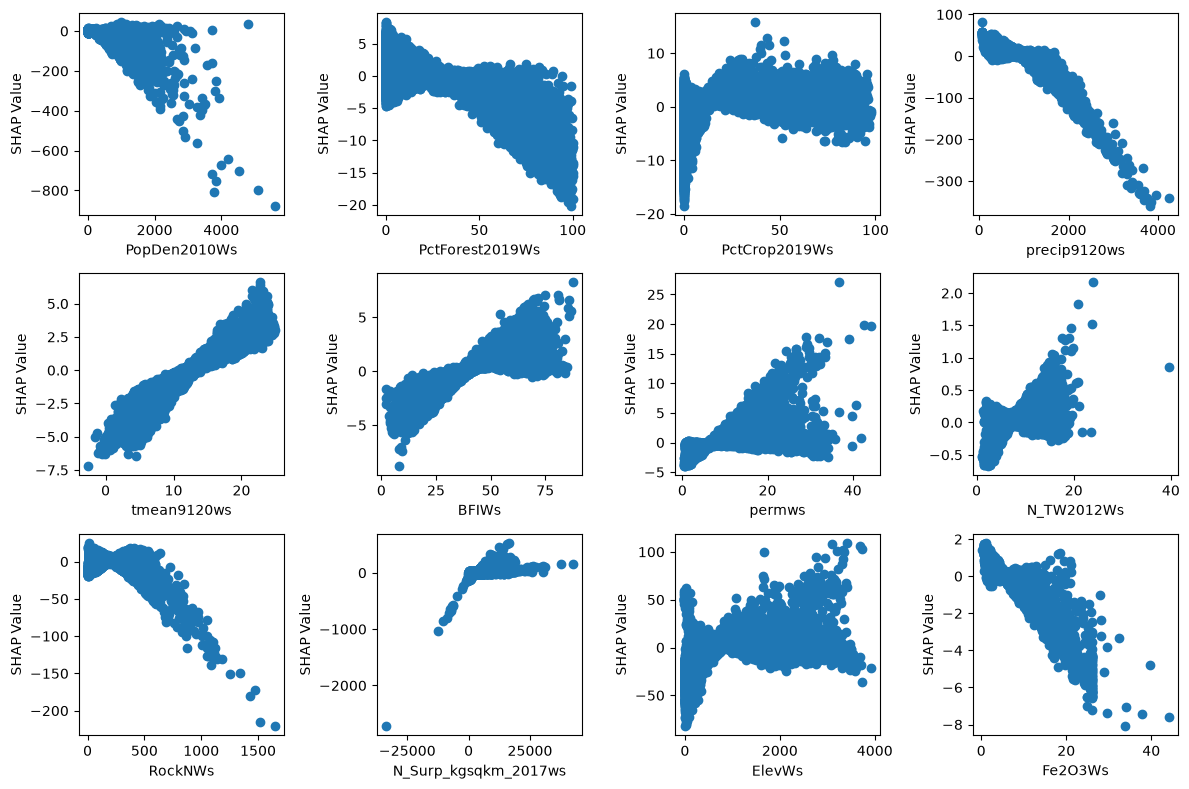

In [14]:
plot_shap_vs_input2(shap_values1[:,:, 0].values, X_input_data.numpy(), names)

# SAVE SHAP RESULTS

In [51]:
import pickle


filename1 = '/torch_SHAP_Values_model0_COMID_All_Observed_sw.pkl'

with open(shap_dir + filename1, "wb") as f:
    pickle.dump(shap_values1, f)

In [ ]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
# Save SHAP Results
filename1 = 'torch_SHAP_Values_DF_COMID_All_Observed_sw.parquet'
#filename = 'torch_SHAP_Values_HUC12_All_Observed_gw.parquet'

filename2 = 'torch_SHAP_Values_COMID_All_Observed_sw.parquet'


table1 = pa.Table.from_pandas(df_shap)
table2 = pa.Table.from_pandas(shap_values1)

pq.write_table(table, future_dir + filename1)
pq.write_table(shap_values1, future_dir + filename2)
